<!--- sf-header --->
<table align="left">
<tr>
  <td style="text-align: center">
    <a href="https://console.cloud.google.com/vertex-ai/colab/import/https%3A%2F%2Fraw.githubusercontent.com%2Fstatmike%2Fscale-forecasting%2Fmain%2Fnotebooks%2F10_registry_operations_and_scale.ipynb">
      <img width="32px" src="https://lh3.googleusercontent.com/JmcxdQi-qOpctIvWKgPtrzZdJJK-J3sWE1RsfjZNwshCFgE_9fULcNpuXYTilIR2hjwN" alt="Colab Enterprise logo">
      <br>Run in<br>Colab Enterprise
    </a>
  </td>
</tr>
</table>
<br clear="left"/>

> **Run in Colab Enterprise:** click the badge to import this notebook, pick a runtime, and
> **Run all**. The Terraform-deployed templates already carry the `SF_*` run identity in their env,
> so there's no environment cell to fill in. Runs on the **`sf-main`** runtime template (Python 3.11). See
> [`docs/notebook_runtimes.md`](https://github.com/statmike/scale-forecasting/blob/main/docs/notebook_runtimes.md)
> for the per-notebook template mapping and the headless acceptance harness.


# 10 · Registry Operations, Pre-Flight Feasibility, All 5 Launch Pathways & 100k Scale Review

This notebook covers **Day-2 production operations** (`Registry` and `Forecaster` in `sdk.py`), **pre-flight feasibility & repair/settle/cancel workflows**, **all 5 production launch pathways** (including live execution of the Cloud Composer 3 / Airflow `airflow_tasks` DAG sequence against a GCS-staged config), and **100,000-series multi-engine benchmark analysis** across Dataproc Spark, Vertex AI Ray, Vertex CustomJob, GCE, and BigQuery ML — **with zero raw SQL boilerplate**.

```mermaid
flowchart TB
    subgraph Ops["Zero-SQL Registry & Operational Verbs (sdk.Registry · Forecaster)"]
        D1["reg.doctor() · reg.runs_df()<br/>Dataset, Views, Iceberg & Run Discovery"]
        D2["forecaster.feasibility() · cohorts_df() · jobs_df()<br/>Pre-Flight Fold Geometry & Job Sizing"]
        D3["forecaster.retry() · settle() · cancel()<br/>Preview-Safe Repair & Drain Verbs"]
        D4["reg.probe(run_id) · snapshot() · export()<br/>Live Platform Probes & Time-Travel Clones"]
    end
    subgraph Pathways["All 5 Production Launch Pathways"]
        L1["1. Python SDK: Forecaster(cfg).run_live()"]
        L2["2. CLI & Cloud Batch: launch_plan.stage_run(cfg)"]
        L3["3. Cloud Composer 3: emit_airflow() + airflow_tasks.*"]
        L4["4. Spark Connect: Forecaster.run(spark=session)"]
        L5["5. Direct Cluster Embedding: spark_io.run_group / ray_io.chunk_cells"]
    end
    Ops & Pathways --> SCALE["100,000-Series Benchmark Review<br/>reg.runs_df(status='COMPLETED')"]
```

## Act 1 · Cloud Bootstrap & Deployment Resolution

On a managed cloud notebook (**Colab Enterprise**, **Vertex AI Workbench**) the bootstrap cell below clones or updates the repository and installs the locked dependency set (`uv.lock`) into an isolated `.colab-deps` prefix so `import scale_forecasting` resolves against the exact package versions every cloud worker uses. **In a local clone with `.venv`, this cell is a fast no-op.**

In [1]:
# Cloud bootstrap: clone + install the LOCKED dependency set (uv.lock) so
# `import scale_forecasting` resolves against the exact versions every other surface runs.
import importlib.util
import os
import shutil
import subprocess
import sys

REPO_URL = os.environ.get("SF_REPO_URL", "https://github.com/statmike/scale-forecasting.git")
REPO_DIR = os.environ.get("SF_REPO_DIR", "scale-forecasting")
EXTRAS = []

if importlib.util.find_spec("scale_forecasting") is None:
    if not os.path.isdir(REPO_DIR):
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, REPO_DIR], check=True)
    uv = shutil.which("uv")
    if uv is None:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", "uv"], check=True)
        uv = shutil.which("uv") or "uv"
    reqs = os.path.abspath(os.path.join(REPO_DIR, "colab-requirements.txt"))
    extra_flags = [f for e in EXTRAS for f in ("--extra", e)]
    subprocess.run(
        [uv, "export", "--frozen", "--no-emit-project", "--no-hashes", "--no-dev", *extra_flags, "-o", reqs],
        cwd=REPO_DIR,
        check=True,
    )
    target = os.path.abspath(os.path.join(REPO_DIR, ".colab-deps"))
    subprocess.run(
        [uv, "pip", "install", "--python", sys.executable, "--target", target, "-r", reqs],
        check=True,
    )
    sys.path.insert(0, target)
    sys.path.insert(0, os.path.join(REPO_DIR, "src"))
    print("installed scale_forecasting from", REPO_DIR)
else:
    print("scale_forecasting already importable — skipping bootstrap")

scale_forecasting already importable — skipping bootstrap


### Resolve the Live GCP Deployment (`Settings.resolve()`)

`Settings.resolve()` reads the `SF_*` environment variables (`SF_PROJECT_ID`, `SF_REGION`, `SF_DATASET_ID`, `SF_WAREHOUSE_URI`, `SF_CONNECTION`, `SF_COMPUTE_SA`) pre-populated by Terraform in the `sf-main` runtime template (or your local shell).

In [2]:
from google.cloud import bigquery
from scale_forecasting.settings import Settings

settings = Settings.resolve()
client = bigquery.Client(project=settings.project_id)
DATASET = settings.dataset_ref
print(f"Deployment: {DATASET} | Region: {settings.region} | Bucket: {settings.warehouse_uri}")

Deployment: statmike-scale-forecasting.scale_forecasting | Region: us-central1 | Bucket: gs://statmike-scale-forecasting-warehouse/warehouse


## Act 1 · Registry Health Audit (`reg.doctor()`) & Zero-SQL Run Discovery (`reg.runs_df()`)

`Registry(settings=settings).doctor()` performs a non-destructive read-only audit of all 5 registry tables, 5 analytical SQL views, in-flight `RUNNING` rows, and orphaned GCS artifact prefixes. `reg.runs_df(limit=10)` returns the recent run ledger from `v_run_summary` as a clean DataFrame without writing a single line of SQL.

In [3]:
import pandas as pd
from scale_forecasting import Forecaster, Registry, RunConfig

reg = Registry(settings=settings)
report = reg.doctor()
print("Registry healthy:", report.healthy)
display(pd.DataFrame([
    {"table": t.table, "exists": t.exists, "rows": t.rows}
    for t in report.tables
]))

# Zero-SQL discovery of the 10 most recent runs from v_run_summary
recent_df = reg.runs_df(limit=10)
display(recent_df)

Registry healthy: False


,table,exists,rows
0,run_registry,True,318
1,run_jobs,True,536
2,forecast_metadata,True,5487695
3,forecast_predictions,True,153607872
4,backtest_oof,True,10910856


,run_id,created_at,status,python_runtime,n_series,n_models,backtest_on,runtime_seconds,total_wall_s,overhead_seconds,overhead_fraction,dcu_milli_seconds
0,nb10-airflow-dag-1791145724-afbb70e809e4,2026-10-05 01:18:12.361405+00:00,STAGED,spark,5,2,True,NaN,NaN,NaN,NaN,NaN
1,nb07-runb-python-hpo-1791145724-19b23c07b49c,2026-10-04 20:49:12.644643+00:00,COMPLETED,vertex,15,5,True,32.059000,NaN,NaN,NaN,NaN
2,nb08-master-workflow-1791145853-afcf6015f8ee,2026-10-04 20:31:10.263029+00:00,COMPLETED,spark,15,7,True,1499.837347,1372.6,-127.237347,-0.092698,13765500.0
3,nb07-runb-python-hpo-1791145724-2e8b618d2bb4,2026-10-04 20:30:51.693874+00:00,COMPLETED,vertex,15,3,True,340.430846,NaN,NaN,NaN,NaN
4,nb07-runa-native-1791145724-90652bc25fa9,2026-10-04 20:29:03.925843+00:00,COMPLETED,spark,15,2,True,78.554067,NaN,NaN,NaN,NaN
5,nb06-hierarchy-mint-1791145253-bbc069a2c659,2026-10-04 20:21:10.606843+00:00,COMPLETED,vertex,20,3,True,397.611271,NaN,NaN,NaN,NaN
6,nb05-covariates-global-1791144913-6614266f6e2e,2026-10-04 20:15:47.628631+00:00,COMPLETED,vertex,20,5,True,942.548654,NaN,NaN,NaN,NaN
7,nb03-spark-serverless-1791144910-9353ee60d3c4,2026-10-04 20:15:46.153851+00:00,COMPLETED,spark,12,4,True,1567.586063,1420.0,-147.586063,-0.103934,14290500.0
8,nb04-ray-gpu-1791144910-a006aec1bbcf,2026-10-04 20:15:45.936289+00:00,COMPLETED,ray,10,3,True,1272.421430,492.2,-780.221430,-1.585172,NaN
9,nb01-bq-native-1791144909-1c0312750f39,2026-10-04 20:15:43.079634+00:00,COMPLETED,spark,50,2,True,243.509616,NaN,NaN,NaN,NaN


## Act 2 · Reattach to Any Historical `run_id`: Feasibility, Cohorts, Jobs & Safe Repair Previews

`Forecaster.from_run_id(RUN_ID, settings=settings)` rehydrates a `Forecaster` directly from the stored `config_json` in `run_registry`.
From that rehydrated instance, we can inspect:
1. **Pre-Flight Feasibility (`hist_forecaster.feasibility()`):** Audits source series history lengths against the required backtest fold geometry.
2. **Cohort Health & Job Sizing (`cohorts_df()`, `jobs_df()`, `reg.probe()`):** Inspects fold coverage, executed VM/cluster sizing, and live platform probes.
3. **Preview-Mode Operational Verbs (`retry(confirm=False)`, `settle(yes=False)`, `cancel(confirm=False)`):** Dry-runs the repair classifier, drain-and-ensemble settler, and job cancellation plan without mutating any state.

Selected run_id: nb07-runb-python-hpo-1791145724-19b23c07b49c


,rank,model_type,family,is_ensemble,ensemble_id,compute_engine,n_series,decision_metric,score,pooled_wape,...,mean_mae,mean_rmse,mean_coverage,mean_interval_score,mean_fit_seconds,median_fit_seconds,no_artifact_rate,n_predictions,lift_vs_best_base,lift_pct
0,1,arima_plus,native,False,None,bigquery,15,wape,0.358122,0.116795,...,10.926623,15.050516,0.592857,57.506210,NaN,NaN,1.0,420,NaN,NaN
1,2,timesfm,native,False,None,bigquery,15,wape,0.361305,0.114332,...,11.005670,15.294330,0.761905,50.668533,NaN,NaN,1.0,420,NaN,NaN
2,3,ensemble_xgb,ensemble,True,51d4ece95c85,ensemble,15,wape,0.366988,0.115158,...,10.911633,15.023980,NaN,NaN,NaN,NaN,0.0,840,-0.008866,-0.024757
3,4,ensemble_ridge,ensemble,True,51d4ece95c85,ensemble,15,wape,0.368492,0.115912,...,10.855356,14.903887,NaN,NaN,NaN,NaN,0.0,840,-0.010371,-0.028959
4,5,ensemble_nnls,ensemble,True,51d4ece95c85,ensemble,15,wape,0.369598,0.116379,...,10.877367,14.877993,NaN,NaN,NaN,NaN,0.0,840,-0.011476,-0.032045
5,6,ensemble_inverse_error,ensemble,True,51d4ece95c85,ensemble,15,wape,0.372801,0.117301,...,10.920454,14.928834,NaN,NaN,NaN,NaN,1.0,0,-0.014680,-0.040991
6,7,holtwinters,statistical,False,None,vertex,15,wape,0.391809,0.156864,...,14.251815,19.000227,0.641667,74.878023,2.145524,2.313616,1.0,420,NaN,NaN
7,8,lightgbm,ml,False,None,vertex,15,wape,0.431822,0.146606,...,13.382693,17.786898,0.284524,93.739764,1.060315,1.063863,1.0,420,NaN,NaN
8,9,theta,statistical,False,None,vertex,15,wape,0.443389,0.158292,...,14.614160,18.970049,0.995238,262.555232,4.567663,4.013818,1.0,420,NaN,NaN


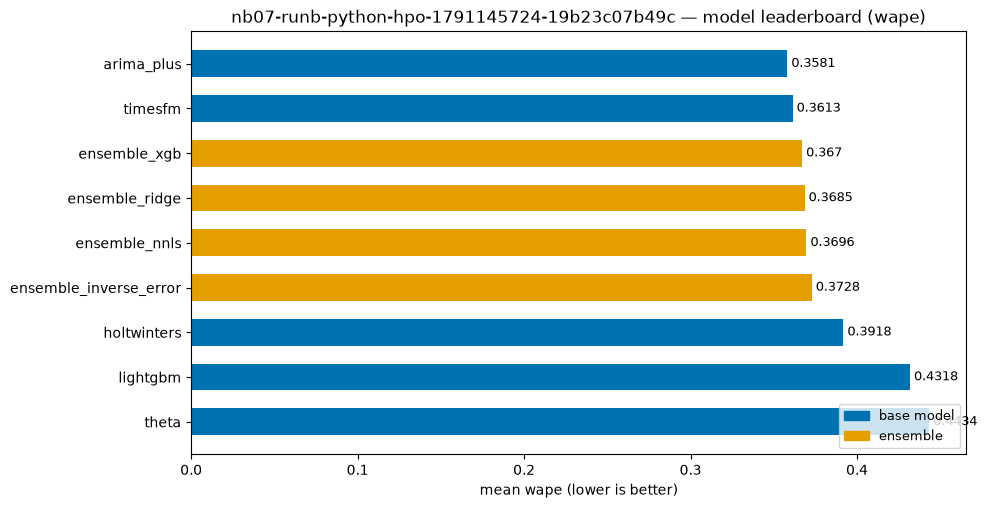

--- Pre-Flight Fold Feasibility Report (hist_forecaster.feasibility) ---


feasibility: 15 series x 5 models = 75 cells
  fits: 225 (322,200 training rows) = 2.942 whole-history fits per cell
  2 of 2 folds: 15 series (100.0%) — all folds
  min_train=180 is within budget: up to 1404 still keeps 90% of series at full folds
--- Backtest Cohort Coverage & Per-Family Job Telemetry ---


,model_type,family,is_ensemble,n_series,score,pooled_wape,n_comparable_series,n_full,n_reduced,n_unscored,n_failed,n_not_requested,fold_histogram,refit_modes,staleness_gap
0,arima_plus,native,False,15,0.358122,0.116795,15,15,0,0,0,0,2f:15,per_fold:15,None
1,timesfm,native,False,15,0.361305,0.114332,15,15,0,0,0,0,2f:15,per_fold:15,None
2,ensemble_xgb,ensemble,True,15,0.366988,0.115158,15,0,0,0,0,15,none,per_fold:15,None
3,ensemble_ridge,ensemble,True,15,0.368492,0.115912,15,0,0,0,0,15,none,per_fold:15,None
4,ensemble_nnls,ensemble,True,15,0.369598,0.116379,15,0,0,0,0,15,none,per_fold:15,None
5,ensemble_inverse_error,ensemble,True,15,0.372801,0.117301,15,0,0,0,0,15,none,per_fold:15,None
6,holtwinters,statistical,False,15,0.391809,0.156864,15,15,0,0,0,0,2f:15,per_fold:15,None
7,lightgbm,ml,False,15,0.431822,0.146606,15,15,0,0,0,0,2f:15,per_fold:15,None
8,theta,statistical,False,15,0.443389,0.158292,15,15,0,0,0,0,2f:15,per_fold:15,None


,family,job_key,system_job_id,runtime,status,attempt,hardware,gpu_type,spark_mode,runtime_seconds
0,ensemble,sf-nb07-runb-python-hpo-1791145724-19b23c07b49...,None,bigquery,COMPLETED,1,None,None,None,32.059


Platform job probes: ProbeReport(run_id='nb07-runb-python-hpo-1791145724-19b23c07b49c', status='COMPLETED', escalated=False, families=(FamilyVerdict(family='statistical', runtime=None, registry_status=None, native_state=None, exists=None, verdict='TRUST_REGISTRY', disagreement=False, n_done=30, n_expected=30, detail='', telemetry={}), FamilyVerdict(family='ml', runtime=None, registry_status=None, native_state=None, exists=None, verdict='TRUST_REGISTRY', disagreement=False, n_done=15, n_expected=15, detail='', telemetry={}), FamilyVerdict(family='native', runtime=None, registry_status=None, native_state=None, exists=None, verdict='TRUST_REGISTRY', disagreement=False, n_done=30, n_expected=30, detail='', telemetry={}), FamilyVerdict(family='ensemble', runtime='bigquery', registry_status='COMPLETED', native_state=None, exists=None, verdict='TRUST_REGISTRY', disagreement=False, n_done=60, n_expected=60, detail='', telemetry={})), disagreement=False)
--- Safe Preview-Mode Day-2 Verbs (confi

Retry preview executed: False | verdict counts: {'SKIP_ALREADY_DONE': 75} | submittable models: ()


Settle preview: SettleReport(run_id='nb07-runb-python-hpo-1791145724-19b23c07b49c', plan=SettlePlan(run_id='nb07-runb-python-hpo-1791145724-19b23c07b49c', header_status='COMPLETED', items=(SettleItem(family='statistical', runtime=None, registry_status=None, verdict='TRUST_REGISTRY', native_state=None, n_done=30, n_expected=30, decision=None, note='left alone: verdict TRUST_REGISTRY'), SettleItem(family='ml', runtime=None, registry_status=None, verdict='TRUST_REGISTRY', native_state=None, n_done=15, n_expected=15, decision=None, note='left alone: verdict TRUST_REGISTRY'), SettleItem(family='native', runtime=None, registry_status=None, verdict='TRUST_REGISTRY', native_state=None, n_done=30, n_expected=30, decision=None, note='left alone: verdict TRUST_REGISTRY'), SettleItem(family='ensemble', runtime='bigquery', registry_status='COMPLETED', verdict='TRUST_REGISTRY', native_state=None, n_done=60, n_expected=60, decision=None, note='already COMPLETED, untouched'))), executed=False, outcome

Cancel preview: CancelReport(run_id='nb07-runb-python-hpo-1791145724-19b23c07b49c', plan=CancelPlan(run_id='nb07-runb-python-hpo-1791145724-19b23c07b49c', items=(CancelPlanItem(family='statistical', runtime=None, registry_status=None, native_state=None, cancellable=True, n_done=30, n_expected=30, note='will cancel; 30/30 series landed (retained)'), CancelPlanItem(family='ml', runtime=None, registry_status=None, native_state=None, cancellable=True, n_done=15, n_expected=15, note='will cancel; 15/15 series landed (retained)'), CancelPlanItem(family='native', runtime=None, registry_status=None, native_state=None, cancellable=True, n_done=30, n_expected=30, note='will cancel; 30/30 series landed (retained)'), CancelPlanItem(family='ensemble', runtime='bigquery', registry_status='COMPLETED', native_state=None, cancellable=False, n_done=60, n_expected=60, note='already COMPLETED, untouched')), ensemble_suppressed=True), executed=False, outcomes=(), header_status=None, actor=None, reason='')


In [4]:
import matplotlib.pyplot as plt
from scale_forecasting import plot_leaderboard

RUN_ID = None  # None -> auto-select most recent COMPLETED run
if RUN_ID is None and not recent_df.empty:
    completed = recent_df[recent_df["status"] == "COMPLETED"]
    RUN_ID = str((completed if not completed.empty else recent_df)["run_id"].iloc[0])

print("Selected run_id:", RUN_ID)
if RUN_ID:
    hist_forecaster = Forecaster.from_run_id(RUN_ID, settings=settings)
    display(hist_forecaster.leaderboard_df())
    plot_leaderboard(hist_forecaster.review_run())
    plt.show()

    print("--- Pre-Flight Fold Feasibility Report (hist_forecaster.feasibility) ---")
    feas = hist_forecaster.feasibility()
    print("\n".join(feas))

    print("--- Backtest Cohort Coverage & Per-Family Job Telemetry ---")
    display(hist_forecaster.cohorts_df())
    display(hist_forecaster.jobs_df())
    print("Platform job probes:", reg.probe(RUN_ID))

    print("--- Safe Preview-Mode Day-2 Verbs (confirm=False / yes=False) ---")
    retry_preview = hist_forecaster.retry(confirm=False)
    print("Retry preview executed:", retry_preview.executed, "| verdict counts:", retry_preview.plan.counts, "| submittable models:", retry_preview.plan.models)
    settle_preview = hist_forecaster.settle(yes=False)
    print("Settle preview:", settle_preview)
    cancel_preview = hist_forecaster.cancel(confirm=False)
    print("Cancel preview:", cancel_preview)

## Act 3 · All 5 Production Launch Pathways & Live Cloud Composer 3 (`airflow_tasks`) Execution

`scale-forecasting` executes the **exact same `RunConfig`** across all **5 launch surfaces**:
1. **Python SDK (`Forecaster`):** `Forecaster(cfg).run()` / `Forecaster(cfg).run_live()` (used throughout Notebooks `01`–`08`).
2. **CLI & Headless Cloud Batch (`launch_plan.stage_run`):** Uploads `src.zip` + `config.json` to GCS (`gs://<code_bucket>/runs/<run_id>.json`) and emits the exact `python -m scale_forecasting.main` and `gcloud` commands for Cloud Batch / Cloud Run Jobs.
3. **Cloud Composer 3 / Apache Airflow (`emit_airflow` + `airflow_tasks`):** Generates a self-contained Airflow DAG whose `PythonOperator` nodes call `scale_forecasting.airflow_tasks` (`begin_run` $\rightarrow$ `run_family` / `run_native` $\rightarrow$ `retry_families` $\rightarrow$ `run_ensemble` $\rightarrow$ `finalize_run`).
4. **Interactive Spark Connect (`Forecaster.run(spark=spark)`):** Drives a remote Dataproc 2.3 cluster over gRPC (Notebook `03`).
5. **Direct Cluster Engine Embedding (`spark_io.run_group` & `ray_io.chunk_cells`):** Embeds the pure worker UDF inside an existing Spark or Ray pipeline (Notebooks `03` & `04`).

Below, we stage a production `RunConfig` to GCS with `stage_run()`, emit its Cloud Composer 3 DAG `.py` source with `emit_airflow()`, and **execute the exact `airflow_tasks` DAG node sequence live** against the GCS-staged `config_uri`!

In [5]:
import time
from scale_forecasting import airflow_tasks, launch_plan

dag_cfg = RunConfig(
    run_name=f"nb10 airflow dag {int(time.time())}",
    data={"source_table": "source_series_native", "horizon": 14, "series_limit": 5},
    models=["arima_plus", "timesfm"],
    features={"holidays": ["US"]},
    backtest={"enabled": True, "n_folds": 2, "horizon": 14, "step": 14},
    ensemble={"enabled": True, "strategies": ["mean", "inverse_error", "nnls"]},
)
dag_forecaster = Forecaster(dag_cfg, settings=settings)

# Pathway 2: Stage config + code archive to GCS via launch_plan.stage_run()
staged_plan = launch_plan.stage_run(dag_cfg, settings=settings)
print("Staged config_uri:", staged_plan.config_uri)
print("Emitted CLI command:", staged_plan.commands["main"].universal)

# Pathway 3A: Emit the Cloud Composer 3 / Airflow DAG Python file
dag_source = dag_forecaster.emit_airflow(with_retry=True)
print("\n--- Generated Cloud Composer 3 DAG (first 30 lines) ---")
print("\n".join(dag_source.splitlines()[:30]))

# Pathway 3B: Execute the exact Airflow TaskFlow node sequence live against staged_plan.config_uri!
print("\n--- Executing Airflow DAG Task Callables Live (begin_run -> run_native -> retry_families -> run_ensemble -> finalize_run) ---")
dag_run_id = airflow_tasks.begin_run(staged_plan.config_uri)
airflow_tasks.run_native(staged_plan.config_uri)
retry_msg = airflow_tasks.retry_families(staged_plan.config_uri)
print("Airflow retry node:", retry_msg)
airflow_tasks.run_ensemble(staged_plan.config_uri)
airflow_tasks.finalize_run(staged_plan.config_uri)

dag_completed = Forecaster.from_run_id(dag_run_id, settings=settings)
display(dag_completed.leaderboard_df())
display(dag_completed.jobs_df())

Staged config_uri: gs://statmike-scale-forecasting-code/runs/nb10-airflow-dag-1791163309-e1a529e2e091.json
Emitted CLI command: python -m scale_forecasting.main --config-uri gs://statmike-scale-forecasting-code/runs/nb10-airflow-dag-1791163309-e1a529e2e091.json

--- Generated Cloud Composer 3 DAG (first 30 lines) ---
"""Auto-generated Airflow DAG for scale-forecasting run nb10-airflow-dag-1791163309-e1a529e2e091.

Generated by scale_forecasting.airflow_emit — do not edit by hand. To change the run, edit the
config and re-emit; the run_id (this file's identity) is a digest of that config.

Every task calls a callable in scale_forecasting.airflow_tasks against the staged config below, so
this DAG runs the identical building blocks as a local ``python -m scale_forecasting.main`` run.
"""

from __future__ import annotations

import pendulum
from airflow import DAG
from airflow.operators.python import PythonOperator

from scale_forecasting import airflow_tasks

# The staged config whose dig

Airflow retry node: retry node: nothing to repair in run nb10-airflow-dag-1791163309-e1a529e2e091


,rank,model_type,family,is_ensemble,ensemble_id,compute_engine,n_series,decision_metric,score,pooled_wape,...,mean_mae,mean_rmse,mean_coverage,mean_interval_score,mean_fit_seconds,median_fit_seconds,no_artifact_rate,n_predictions,lift_vs_best_base,lift_pct
0,1,timesfm,native,False,None,bigquery,5,wape,0.329789,0.106544,...,10.830982,14.425244,0.778571,53.944902,None,None,1.0,70,NaN,NaN
1,2,ensemble_inverse_error,ensemble,True,fdbc4b03f8ab,ensemble,5,wape,0.331198,0.105832,...,10.566167,13.653403,NaN,NaN,None,None,1.0,70,-0.001409,-0.004273
2,3,ensemble_mean,ensemble,True,fdbc4b03f8ab,ensemble,5,wape,0.331395,0.105603,...,10.563350,13.632530,NaN,NaN,None,None,1.0,70,-0.001606,-0.004870
3,4,ensemble_nnls,ensemble,True,fdbc4b03f8ab,ensemble,5,wape,0.333566,0.105790,...,10.641064,13.592470,NaN,NaN,None,None,0.0,70,-0.003777,-0.011454
4,5,arima_plus,native,False,None,bigquery,5,wape,0.336974,0.107392,...,10.840938,13.832942,0.585714,56.326545,None,None,1.0,70,NaN,NaN


,family,job_key,system_job_id,runtime,status,attempt,hardware,gpu_type,spark_mode,runtime_seconds
0,ensemble,sf-nb10-airflow-dag-1791163309-e1a529e2e091-en...,sf-nb10-airflow-dag-1791163309-e1a529e2e091-en...,bigquery,COMPLETED,1,None,None,None,11.86070
1,native,sf-nb10-airflow-dag-1791163309-e1a529e2e091-na...,sf-nb10-airflow-dag-1791163309-e1a529e2e091-na...,bigquery,COMPLETED,1,None,None,None,76.06567


## Act 4 · Executive 100,000-Series Cross-Platform Benchmark Review (`reg.runs_df`)

Finally, let's use `reg.runs_df(limit=25, status='COMPLETED')` to inspect the completed runs in the registry sorted by `n_series` descending — comparing compute throughput, cluster provisioning overhead, and execution wall-clock across **Dataproc Spark**, **Vertex AI Ray**, **Vertex CustomJob**, **GCE**, and **BigQuery ML**.

In [6]:
completed_runs = reg.runs_df(limit=25, status="COMPLETED")
scale_df = completed_runs.sort_values(["n_series", "created_at"], ascending=[False, False]).head(15)
display(scale_df)

,run_id,created_at,status,python_runtime,n_series,n_models,backtest_on,runtime_seconds,total_wall_s,overhead_seconds,overhead_fraction,dcu_milli_seconds
9,nb01-bq-native-1791144909-1c0312750f39,2026-10-04 20:15:43.079634+00:00,COMPLETED,spark,50,2,True,243.509616,NaN,NaN,NaN,NaN
21,smoke-32-covariates-three-tier-77d614b503d1,2026-09-30 22:26:19.026367+00:00,COMPLETED,spark,50,8,True,2190.079879,2026.9,-163.179879,-0.080507,18480800.0
22,smoke-29-features-on-e4ad80d90817,2026-09-26 23:14:02.497171+00:00,COMPLETED,spark,50,6,True,1754.344605,1609.7,-144.644605,-0.089858,32103150.0
23,smoke-31-features-exog-8bc96fed0e7a,2026-09-26 03:01:40.410691+00:00,COMPLETED,spark,50,6,True,1703.850991,1605.1,-98.750991,-0.061523,33026950.0
24,smoke-28-features-off-f9298e722d7a,2026-09-26 01:26:36.381425+00:00,COMPLETED,spark,50,6,True,1644.531022,1398.1,-246.431022,-0.176261,18501150.0
19,smoke-35-hierarchy-reconciliation-80a8810304fc,2026-09-30 22:26:49.168847+00:00,COMPLETED,spark,40,4,True,1551.277615,1346.5,-204.777615,-0.152081,10149375.0
20,smoke-33-expanded-stats-ml-dfb077c0de90,2026-09-30 22:26:35.643489+00:00,COMPLETED,spark,25,8,True,2662.838383,2380.1,-282.738383,-0.118793,23052325.0
16,smoke-36-covariate-fallback-multi-runtime-301a...,2026-10-01 19:32:36.648834+00:00,COMPLETED,spark,24,8,True,2635.465330,2497.4,-138.065330,-0.055284,25657600.0
17,smoke-37-hierarchy-covariates-ensemble-e6be5fe...,2026-10-01 19:29:37.098734+00:00,COMPLETED,spark,24,4,True,2003.768934,1862.0,-141.768934,-0.076138,18958350.0
5,nb06-hierarchy-mint-1791145253-bbc069a2c659,2026-10-04 20:21:10.606843+00:00,COMPLETED,vertex,20,3,True,397.611271,NaN,NaN,NaN,NaN
